<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/HW1_Regression_with_inference_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание №1 (base). Часть 1**

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;

**Максимальная оценка за дз**
> Оценка за первую часть домашки = $min(\text{ваш балл}, 7)$


**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.**

Если нет одного и/или другого, то часть баллов за соответствующее задание снимается.

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
from sklearn.impute import SimpleImputer
from ydata_profiling import ProfileReport
import association_metrics as am
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE, root_mean_squared_error as RMSE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
import pickle
import os
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning
)

random.seed(42)
np.random.seed(42)

Давайте зафиксируем важный момент.

**Задание 0 (0 баллов).**
Изучите и ответье на вопрос: для чего фиксируем сиды в домашках?

Мы фиксируем сиды для того, чтобы обеспечить воспроизводимость, которая, в рамках домашек, нам нужна, чтобы проверяющий получил такие же результаты, как и студент выполняющий это задание. То есть очень важно, чтобы все случайные операции давали одинаковый результат при каждом запуске, иначе сравнение или проверка, как в нашем случае, будет просто некорректна.

# **Часть 1 | EDA и визуализация**

Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков (2.5 балла)
- Визуализации признаков и их анализ (1 балл)

Всего можно набрать 3.5 основных балла и 0.65 бонусных. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (2.5 балла)**

In [230]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1 (0.5 балла)**

Вы уже встречались с pandas в первой половине семестра. Теперь будем постоянно (кроме некоторых случаев) использовать его для анализа данных и наслаивать навыки. Выполните операции, направленные на практику основных действий с `pandas`:

**0.1 балла**
- [ ] Отобразите 30 случайных строк тренировочного датасета.
- [ ] Отобразите первые 5 и последние 5 объектов тестового датасета
- [ ] Посмотрите, есть ли в датасете пропуски. Запишите/выведите названия колонок, для которых есть пропущенные значения
- [ ] Посмотрите, есть ли в данных явные дубликаты


**0.2 балла**
Ответьте на вопросы:
- [ ] Выводы о чем можно сделать, используя случайные/верхние/нижние строки? А о чем нельзя?
- [ ] Достаточно ли метода duplicated для анализа дубликатов? Почему?

**0.15 балла**
- [ ] Постройте дашборд, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling)

In [231]:
# Рандомные 30 строк трейн дата сета
df_train.sample(n=30, random_state=42)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
6565,Renault KWID Climber 1.0 MT BSIV,2019,300000,35000,Petrol,Individual,Manual,First Owner,23.01 kmpl,999 CC,67 bhp,91Nm@ 4250rpm,5.0
2943,Maruti Wagon R LXI,2013,225000,58343,Petrol,Trustmark Dealer,Manual,First Owner,21.79 kmpl,998 CC,67.05 bhp,90Nm@ 3500rpm,5.0
2024,Hyundai i20 Asta 1.2,2013,360000,30000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
263,Hyundai i20 1.2 Asta,2010,300000,70000,Petrol,Individual,Manual,First Owner,17.0 kmpl,1197 CC,80 bhp,"11.4 kgm at 4,000 rpm",5.0
4586,Skoda Octavia L and K 1.9 TDI MT,2005,250000,120000,Diesel,Individual,Manual,Third Owner,16.4 kmpl,1896 CC,90 bhp,"21.4@ 1,900(kgm@ rpm)",5.0
4479,Maruti Ciaz ZXi,2016,700000,20000,Petrol,Individual,Manual,First Owner,20.73 kmpl,1373 CC,91.1 bhp,130Nm@ 4000rpm,5.0
4881,Hyundai Grand i10 1.2 Kappa Magna BSIV,2017,445000,27000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0
3583,Ford Ecosport 1.5 DV5 MT Trend,2016,515000,68609,Diesel,Dealer,Manual,First Owner,22.7 kmpl,1498 CC,89.84 bhp,204Nm@ 2000-2750rpm,5.0
6361,Hyundai Verna 1.4 VTVT,2014,500000,33400,Petrol,Individual,Manual,First Owner,17.43 kmpl,1396 CC,105.5 bhp,135.3Nm@ 5000rpm,5.0
4108,Hyundai i20 Era 1.2,2015,490000,45900,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,114.7Nm@ 4000rpm,5.0


In [232]:
# Первые 5 строк тест датасета
df_test.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Mahindra Xylo E4 BS IV,2010,229999,168000,Diesel,Individual,Manual,First Owner,14.0 kmpl,2498 CC,112 bhp,260 Nm at 1800-2200 rpm,7.0
1,Tata Nexon 1.5 Revotorq XE,2017,665000,25000,Diesel,Individual,Manual,First Owner,21.5 kmpl,1497 CC,108.5 bhp,260Nm@ 1500-2750rpm,5.0
2,Honda Civic 1.8 S AT,2007,175000,218463,Petrol,Individual,Automatic,First Owner,12.9 kmpl,1799 CC,130 bhp,172Nm@ 4300rpm,5.0
3,Honda City i DTEC VX,2015,635000,173000,Diesel,Individual,Manual,First Owner,25.1 kmpl,1498 CC,98.6 bhp,200Nm@ 1750rpm,5.0
4,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.5 kmpl,1172 CC,65 bhp,96 Nm at 3000 rpm,5.0


In [233]:
# Последние 5 строк тест датасета
df_test.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
995,Hyundai i10 Magna 1.1L,2008,250000,100000,Petrol,Individual,Manual,Second Owner,19.81 kmpl,1086 CC,68.05 bhp,99.04Nm@ 4500rpm,5.0
996,Hyundai i20 2015-2017 Sportz 1.2,2017,440000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,114.7Nm@ 4000rpm,5.0
997,Hyundai i20 Era Diesel,2009,340000,40000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
998,Hyundai i10 Asta,2012,350000,25000,Petrol,Individual,Manual,First Owner,20.36 kmpl,1197 CC,78.9 bhp,111.8Nm@ 4000rpm,5.0
999,Honda City i DTec SV,2016,700000,110000,Diesel,Individual,Manual,First Owner,26.0 kmpl,1498 CC,98.6 bhp,200Nm@ 1750rpm,5.0


In [234]:
print("Колонки с пропусками и количество самих пропусков для трейна:\n")
print(df_train.isna().sum()[df_train.isna().sum() > 0])
print("\nКолонки с пропусками и количество самих пропусков для теста:\n")
print(df_test.isna().sum()[df_test.isna().sum() > 0])

Колонки с пропусками и количество самих пропусков для трейна:

mileage      202
engine       202
max_power    196
torque       203
seats        202
dtype: int64

Колонки с пропусками и количество самих пропусков для теста:

mileage      19
engine       19
max_power    19
torque       19
seats        19
dtype: int64


In [235]:
print("Количество дубликатов в трейне:", df_train.duplicated().sum())
print("Количество дубликатов в тесте:", df_test.duplicated().sum())

Количество дубликатов в трейне: 985
Количество дубликатов в тесте: 62


Выводы о чем можно сделать, используя случайные/верхние/нижние строки? А о чем нельзя?

Мы можем увидеть какие признаки есть в нашем датасете, их названия и типы. Можем понять какие из них числовые, какие категориальные и какие текстовые. Можем понять что означает каждый столбец. Можем увидеть неверный формат для какой то колонки. Можем увидеть колонки, которые мы можем удалить, так как они никак не повлияют на обучение модели. Не можем сделать выводы о том, есть ли в датасете пропуски или дубликаты. Если мы видим категориальный признак, то мы не можем сделать вывод о количестве этих категорий. Не можем найти распределения признаков и корреляции между ними.

Достаточно ли метода duplicated для анализа дубликатов? Почему?

Нет, потому что метод duplicated просто возвращает маску, которая говорит, является ли строка дубликатом или нет, но мы не знаем для какой строки эта строка является дубликатом. Также мы не знаем сколько раз дублируется эта строка.

In [236]:
profile_report = ProfileReport(df_train, title='Pandas Profiling Report')
profile_report.to_file("CarsDashboard.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 244.68it/s]


Мы обнаружили пропуски. Давайте избавимся от них.

**(0.05 балла)**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось. Заполнение пропусков проводите для обоих наборов данных, если необходимо

**Важно!**

При заполнении пропусков и в тестовом, и тренировочном наборах данных вы определяетесь со стратегией предобработки пропущенных значений при потенциальной работе модели.

Так как в теоретическом случае вы не имеете доступа к тестовой выборке, то заполняемой значение (у нас — медиана) вы считаете про *тренировочному* набору данных и им же заполняете *тестовый*.

In [237]:
df_train.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

In [238]:
df_train.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0


In [239]:
df_train["mileage"] = df_train["mileage"].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
df_train["engine"] = df_train["engine"].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
df_train["max_power"] = df_train["max_power"].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
df_test["mileage"] = df_test["mileage"].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
df_test["engine"] = df_test["engine"].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
df_test["max_power"] = df_test["max_power"].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
df_train.drop(columns="torque", inplace=True)
df_test.drop(columns="torque", inplace=True)

In [240]:
df_train.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0


In [241]:
df_test.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Mahindra Xylo E4 BS IV,2010,229999,168000,Diesel,Individual,Manual,First Owner,14.0,2498.0,112.0,7.0
1,Tata Nexon 1.5 Revotorq XE,2017,665000,25000,Diesel,Individual,Manual,First Owner,21.5,1497.0,108.5,5.0
2,Honda Civic 1.8 S AT,2007,175000,218463,Petrol,Individual,Automatic,First Owner,12.9,1799.0,130.0,5.0
3,Honda City i DTEC VX,2015,635000,173000,Diesel,Individual,Manual,First Owner,25.1,1498.0,98.6,5.0
4,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.5,1172.0,65.0,5.0


In [242]:
medians = df_train.median(numeric_only=True)
df_train = df_train.fillna(medians)
df_test = df_test.fillna(medians)

print(df_train.isna().sum())
print()
print(df_test.isna().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64


### **Задание 2 (0.5 балла)**

На прошлом шаге вы рассмотрели дубликаты. Однако дубликат может быть связан с не только полным повторением информации в нескольких строках, но и частиным. Например, объект мог был внесен в базу данных с разным значением целевой переменной. В этом шаге займемся такими дублями!

**Ваши действия:**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.1 балла)
- [ ] Отобразите такие объекты (0.15 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.15 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.1 балла)


In [243]:
df_train_without_target = df_train.drop(columns=["selling_price"])
print(df_train_without_target.duplicated().sum())
df_train[df_train_without_target.duplicated()]

1159


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
254,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.90,1197.0,82.00,5.0
258,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.60,1197.0,85.80,5.0
268,Maruti Swift Dzire VXI,2014,400000,70000,Petrol,Individual,Manual,Second Owner,19.10,1197.0,85.80,5.0
324,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.60,1999.0,177.00,5.0
325,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37,2487.0,214.56,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6947,Chevrolet Spark 1.0 LS,2010,140000,60000,Petrol,Individual,Manual,Second Owner,18.00,995.0,62.00,5.0
6984,Ford Freestyle Titanium Plus Diesel BSIV,2018,746000,24000,Diesel,Individual,Manual,First Owner,24.40,1498.0,98.63,5.0
6989,Maruti Swift Dzire VDI,2015,625000,50000,Diesel,Individual,Manual,First Owner,26.59,1248.0,74.00,5.0
6997,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70.00,5.0


In [244]:
df_train = df_train.drop_duplicates(subset=df_train_without_target, keep="first")

In [245]:
df_train = df_train.reset_index(drop=True)

In [246]:
assert df_train.shape == (5840, 12) # Поменял на 12, потому что удалил столбец раньше, чем в 3 задании, потому что при заполнении медианами необходимо было преобразовать столбцы с типом object в float, а один из них пришлось удалить вовсе.

Отлично! Мы избавились от маленьких и явных проблем. Теперь перейдем к более сложным недостаткам полученной таблицы.

### **Задание 3 (0.25 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными — они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Удалите столбец ``torque``


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.
- Стобец ``torque`` мы удаляем для простоты. В идеальном случае, его также стоило бы предобработать.

In [247]:
df_train.head() # Все было сделано ранее на этапе проставление пропусков медианами

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0


In [248]:
df_train.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
seats            float64
dtype: object

### **Задание 4 (0.1 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.

In [249]:
df_train["engine"] = df_train["engine"].round().astype("Int64")
df_train["seats"] = df_train["seats"].round().astype("Int64")

In [250]:
df_train.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,5
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,5
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197,81.86,5


In [251]:
df_test["engine"] = df_test["engine"].round().astype("Int64")
df_test["seats"] = df_test["seats"].round().astype("Int64")

In [252]:
df_test.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Mahindra Xylo E4 BS IV,2010,229999,168000,Diesel,Individual,Manual,First Owner,14.0,2498,112.0,7
1,Tata Nexon 1.5 Revotorq XE,2017,665000,25000,Diesel,Individual,Manual,First Owner,21.5,1497,108.5,5
2,Honda Civic 1.8 S AT,2007,175000,218463,Petrol,Individual,Automatic,First Owner,12.9,1799,130.0,5
3,Honda City i DTEC VX,2015,635000,173000,Diesel,Individual,Manual,First Owner,25.1,1498,98.6,5
4,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.5,1172,65.0,5


In [253]:
data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)

train_data_path = os.path.join(data_dir, 'train.csv')
test_data_path = os.path.join(data_dir, 'test.csv')

df_train.to_csv(train_data_path, index=False)
df_test.to_csv(test_data_path, index=False)

### **Задание 5 (0.15 балла)**

Отлично! Мы провели "косметическую" предобработку и теперь готовы сделать важный шаг в контексте анализа данных. А именно — посмотреть на статистики!

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сделайте вывод.

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

**Примечание:**

Более корректно рассматривать статистики до заполнения пропусков и после, чтобы убедиться, что мы не внесли каких-либо серьезных сдвигов в изначальные рапсределения.

In [254]:
df_train.describe(include="number") 

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.0,5840.000000,5840.0
mean,2013.428425,5.229601e+05,7.395224e+04,19.428611,1429.448973,87.910782,5.426712
std,4.095622,5.354320e+05,6.007114e+04,3.986026,485.662834,31.639585,0.982344
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.0,0.000000,2.0
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.0,68.000000,5.0
50%,2014.000000,4.050000e+05,7.000000e+04,19.300000,1248.0,81.860000,5.0
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.0,99.000000,5.0
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.0,400.000000,14.0


In [255]:
df_train.describe(include="object")

,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,1924,4,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,91,3177,5223,5336,3603


In [256]:
df_test.describe(include="number")

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.0,1000.000000,1000.0
mean,2013.681000,6.179010e+05,71393.341000,19.337480,1454.876,90.844330,5.403
std,4.012149,7.585539e+05,48486.218662,3.951751,521.99574,34.892709,0.912921
min,1995.000000,3.100000e+04,1303.000000,0.000000,624.0,34.200000,4.0
25%,2011.000000,2.500000e+05,37000.000000,16.550000,1197.0,69.000000,5.0
50%,2014.000000,4.349990e+05,61500.000000,19.300000,1248.0,82.425000,5.0
75%,2017.000000,6.700000e+05,100000.000000,22.300000,1582.0,102.000000,5.0
max,2020.000000,6.000000e+06,375000.000000,32.260000,3604.0,280.000000,9.0


In [257]:
df_test.describe(include="object")

,name,fuel,seller_type,transmission,owner
count,1000,1000,1000,1000,1000
unique,621,4,3,2,5
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner
freq,15,534,837,877,623


> **Вывод:** Мы можем сделать вывод, что и на трейне и тесте распределение признаков очень блико, что очень хорошо и говорит о том, что данные хорошо разбиты. Можем увидеть признаки с выбросами, например, целевая переменная selling_price. Также расстояние, которое проехала машина km_driven на трейне имеет очень большой разброс и также выбросы. Также выбросы замечены у max_power. У категориальных же признаков мы можем увидеть очень большое множество значений у признака name.

In [258]:
assert df_train.shape == (5840, 12) # Также поменял на 12, так как ранее был удален один столбец

## **Визуализации (1 балл + 0.5 бонус)**



Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 6 (0.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

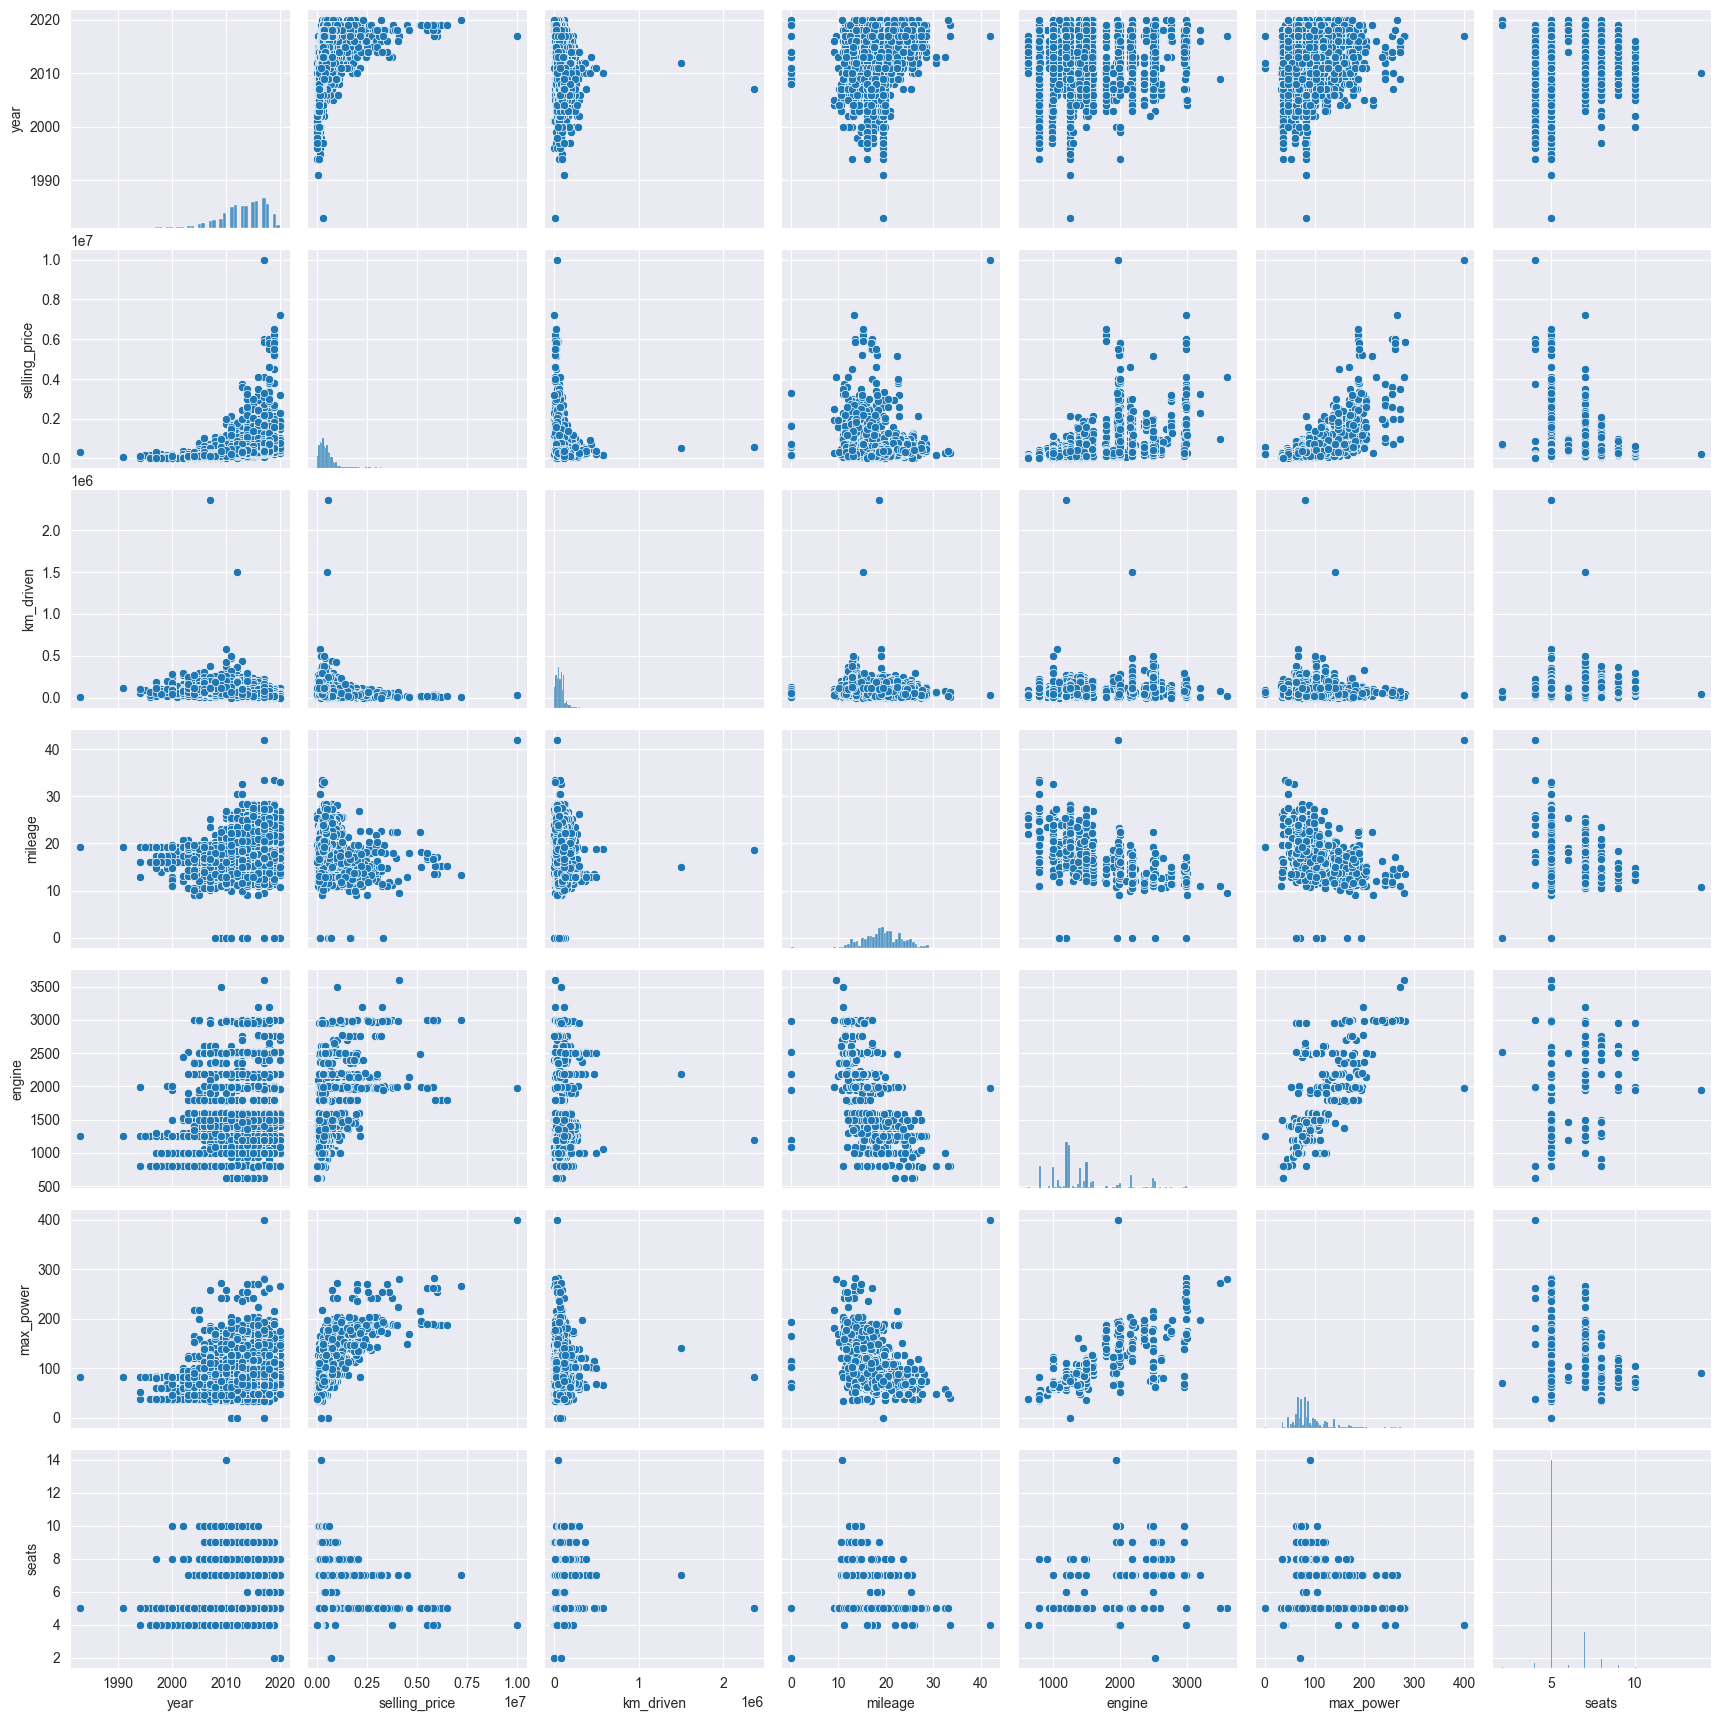

In [259]:
%matplotlib inline

sns.pairplot(df_train)
plt.show()

> Можно ли предположить на основе распределений связь признаков с целевой переменной?

Да, мы можем предположить связь признаков с целевой переменной на основе этих графиков, например, мы можем видеть зависимость цены от года выпуска, расстояния и мощности. Но для некоторых признаков зависимость выражена гораздо слабее.


> Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Мы можем предположить о корреляции признаков engine и max_power, так как мы видим между ними линейную зависимость на графике. Для остальных пар признаках я не увидел выраженную корреляцию.

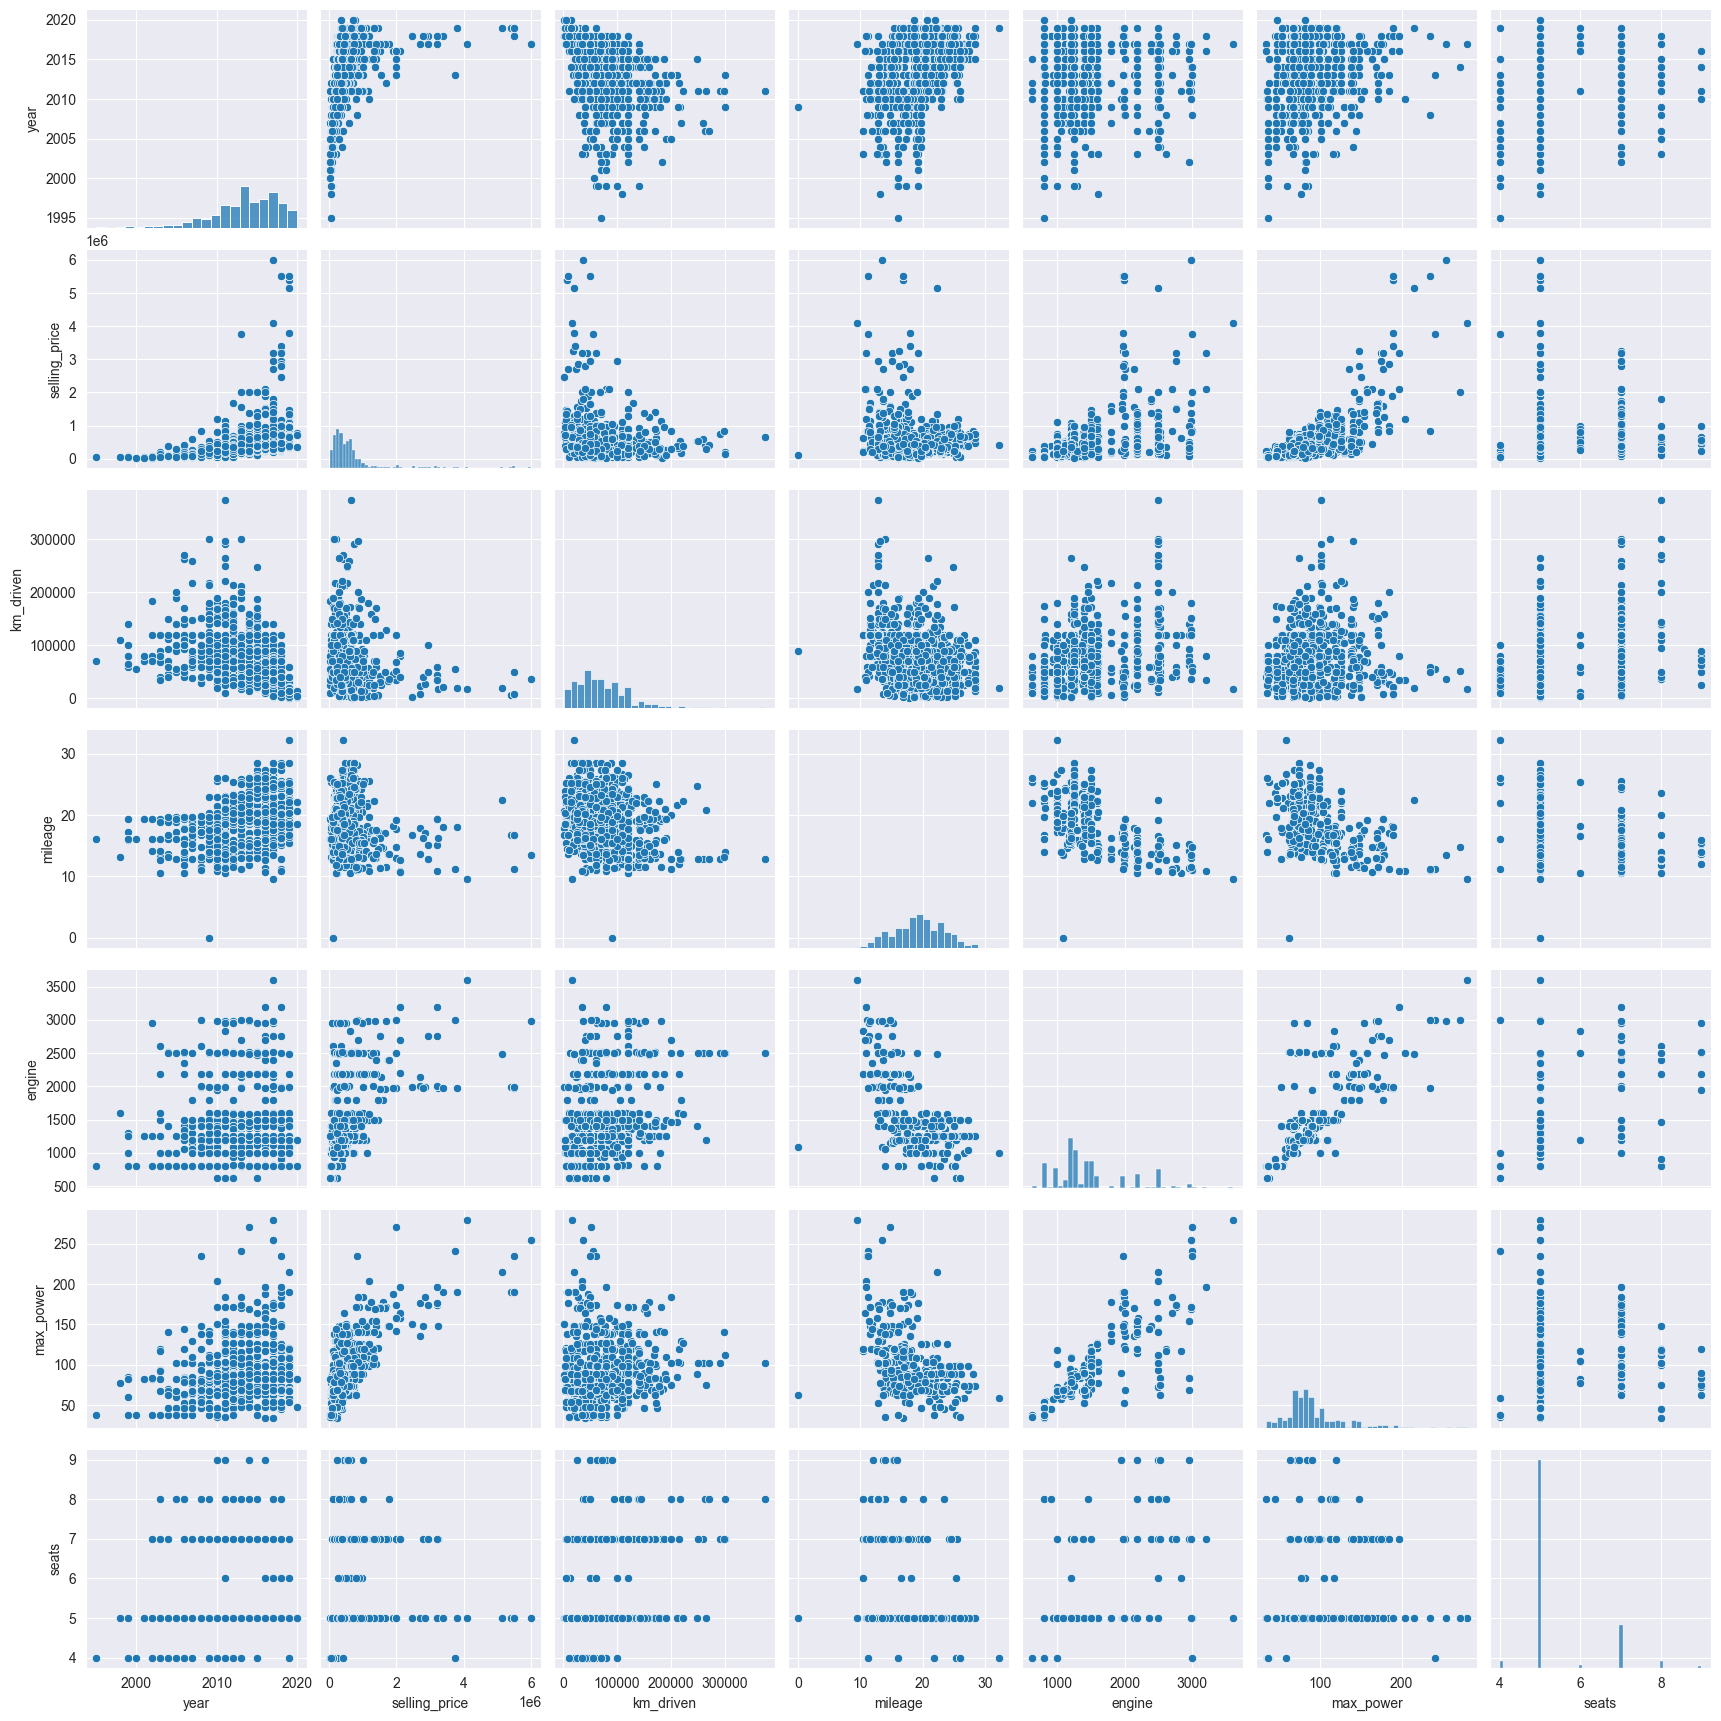

In [260]:
sns.pairplot(df_test)
plt.show()

> Похожими ли оказались совокупности при разделении на трейн и тест?

Да, по графикам я могу сказать, что попарное распределение трейна и теста достаточно близкое, что говорит нам о хорошем разюиении данных.

### **Задание 7 (0.5 балла)**

И так, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)


<Axes: >

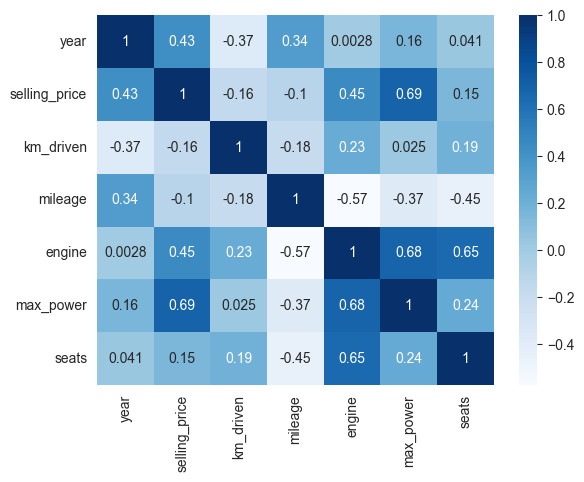

In [261]:
sns.heatmap(df_train.corr(numeric_only=True, method="pearson"), cmap="Blues", annot=True)

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

> Какие 2 признака наименее скоррелированы между собой?

Наименее скоррелированы между собой engine и year, так как их значение ближе всех к нулю среди всех остальных пар.

> Между какими наблюдается довольно сильная положительная линейная зависимость?

Сильную положительную зависимость мы можем увидеть у признаков engine и max_power. Это совпадает с моим выводом после построения графиков попарного распределения. Также мы можем заметить сильную положитьельную линейную зависимость у engine с seats, что явно я бы не сказал по попарному распределению. Также не могу не отметить сильную зависимоть целевой переменной от max_power, тут мы видим наибольшее положительное значение корреляции.

> Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

Мы видим обратную линейную зависимость, но явно сказать, что уменьшается, а что увеличивается мы не можем. Но при взгляде на матрицу попарного распределения видно, что скорее да, чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи.

### **Бонус (0.5 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их **и поясните.**

- Каждая дополнительная визуализация может принести до 0.25 баллов при условии, что она обоснована.

<Axes: >

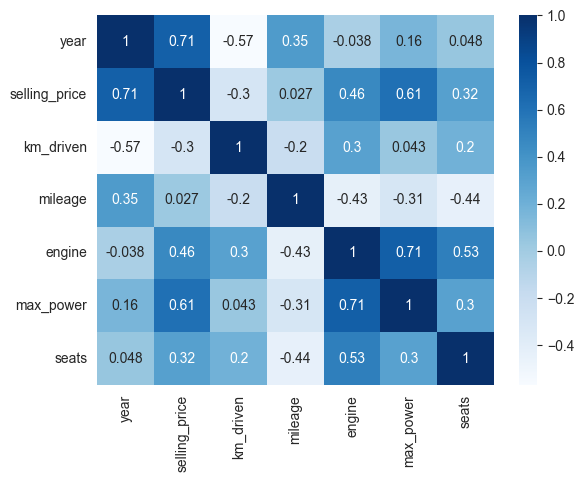

In [262]:
sns.heatmap(df_train.corr(numeric_only=True, method="spearman"), cmap="Blues", annot=True)

> Я решил сделать корреляцию Спирмена, потому что она может нам показать монотонные зависимости, которые могут быть слабо выражены при использовании корреляции Пирсона. И в самом деле, я увидел, что есть сильная положительная монотонная зависимость цены от года. На прошлом графике она была умеренной, что может нам говорить о возможном наличии выбросов.

<Axes: >

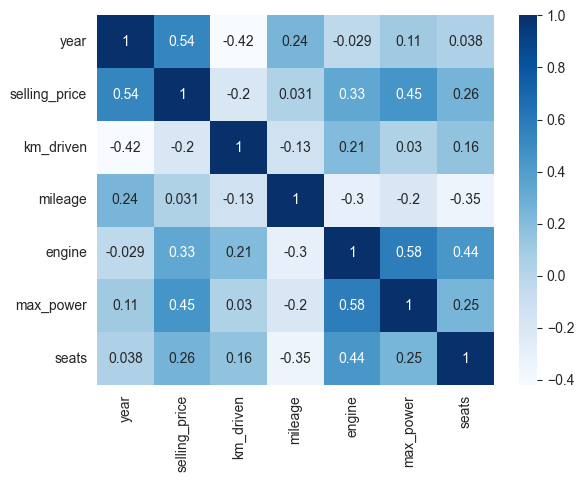

In [263]:
sns.heatmap(df_train.corr(numeric_only=True, method="kendall"), cmap="Blues", annot=True)

> Тут не было сильной необходимости в этой корреляции, но мы увидели подтверждение своих выводов с предыдущих графиков и убедились в стабильности порядка между признаками.

In [264]:
df_train_cat = df_train.apply(lambda x: x.astype("category") if x.dtype == "object" else x)

cramersv = am.CramersV(df_train_cat)

cramersv.fit()

/Users/peter/Documents/HSE/msc/ml/hw1/.venv/lib/python3.13/site-packages/association_metrics/categorical.py:100: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.matrix[x][y] = 1
/Users/peter/Documents/HSE/msc/ml/hw1/.venv/lib/python3.13/s

,name,fuel,seller_type,transmission,owner
name,1.000000,1.000000,0.728837,1.000000,0.719636
fuel,1.000000,1.000000,0.052872,0.042164,0.036350
seller_type,0.728837,0.052872,1.000000,0.212261,0.136822
transmission,1.000000,0.042164,0.212261,1.000000,0.121475
owner,0.719636,0.036350,0.136822,0.121475,1.000000


> Тут я решил посмотреть связи между категориальными признаками, так как до этого мы смотрели только на числовые. По этой табличке я могу сказать, что name очень сильно коррелирует со всем, а также мы знаем, что у него очень много категорий, поэтому нужна будет дополнительная обработка, так как использование этого признака в таком виде может привести к переобучению и неправильной оценке важности других признаков.

# **Часть 2 | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.25 балла;

### **Задание 8 (0.05 балла)**

Сделайте тренировочный и тестовый наборы. Сделайте на тренировочный и тестовый наборы. Она уже даны, достаточно просто отделить целевой признак Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных. Используйте уже имеющиеся данные train и test при разбиении. Если считаете уместным применить какую-то более хитрую технику разбиения — примените, но опишите, зачем.

In [265]:
y_train = df_train["selling_price"]
X_train = df_train.select_dtypes(include="number").drop(columns="selling_price").copy()

In [266]:
X_train.info()
# Я использовал уже готовое разбиение на трейн и тест

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5840 entries, 0 to 5839
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       5840 non-null   int64  
 1   km_driven  5840 non-null   int64  
 2   mileage    5840 non-null   float64
 3   engine     5840 non-null   Int64  
 4   max_power  5840 non-null   float64
 5   seats      5840 non-null   Int64  
dtypes: Int64(2), float64(2), int64(2)
memory usage: 285.3 KB


In [267]:
y_test = df_test["selling_price"]
X_test = df_test.select_dtypes(include="number").drop(columns="selling_price").copy()

### **Задание 9 (0.2 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [268]:
model = LinearRegression()

model.fit(X_train, y_train)

pred_train_model = model.predict(X_train)
pred_test_model = model.predict(X_test)


def chek_metrics(y_true1, y_true2, y_pred1, y_pred2):
    print(f'''
MSE train: {MSE(y_true1, y_pred1):.2f}        
MSE test: {MSE(y_true2, y_pred2):.2f}
r2 train: {r2_score(y_true1, y_pred1):.3f}
r2 test: {r2_score(y_true2, y_pred2):.3f}
RMSE train: {RMSE(y_true1, y_pred1):.2f}
RMSE test: {RMSE(y_true2, y_pred2):.2f}
''')

chek_metrics(y_train, y_test, pred_train_model, pred_test_model)


MSE train: 116873067751.52        
MSE test: 233297548204.61
r2 train: 0.592
r2 test: 0.594
RMSE train: 341867.03
RMSE test: 483008.85



> Я решил добавить еще RMSE, чтобы было нагляднее. Мы можем увидеть, что по средней квадратичной ошибке у нас достаточно большие значения, что значит модель ошибается достаточно серьезно. Но при этом по $r^2$ мы можем видеть, что модель уже понимает цену авто лучше чем просто его среднее. Также на трейн выборке у нас ошибка меньше, но все же велика, если сравнивать со средним значением цены. Мы можем сделать вывод о том, что качество модели ограничено из-за линейности, масштаба или же выбросов. Также явно не хватает влияния категориальных признаков при обучении.

### **Задание 10 (0.15 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

In [269]:
normilizer = StandardScaler()

X_train = pd.DataFrame(data=normilizer.fit_transform(X_train))
X_test = pd.DataFrame(data=normilizer.transform(X_test))

model_scaled = LinearRegression()
model_scaled.fit(X_train, y_train)

pred_train_model_scaled = model_scaled.predict(X_train)
pred_test_model_scaled = model_scaled.predict(X_test)

chek_metrics(y_train, y_test, pred_train_model_scaled, pred_test_model_scaled)


MSE train: 116873067751.52        
MSE test: 233297548204.60
r2 train: 0.592
r2 test: 0.594
RMSE train: 341867.03
RMSE test: 483008.85



### **Задание 11 (0.1 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [270]:
coef = pd.Series(model_scaled.coef_, index=X_train.columns)
coef

0    152843.262358
1    -44148.047511
2     28781.086595
3     61176.857150
4    322779.703236
5    -23220.570226
dtype: float64

> Наибольший коэффициент мы можем увидеть у признака max_power. Следовательно он оказывается самым информативным.

### **Задание 12 (0.25 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [271]:
model_l1 = Lasso()

model_l1.fit(X_train, y_train)

pred_train_model_l1 = model_l1.predict(X_train)
pred_test_model_l1 = model_l1.predict(X_test)

chek_metrics(y_train, y_test, pred_train_model_l1, pred_test_model_l1)


MSE train: 116873067761.64        
MSE test: 233298219170.76
r2 train: 0.592
r2 test: 0.594
RMSE train: 341867.03
RMSE test: 483009.54



In [272]:
pd.Series(model_l1.coef_, index=X_train.columns)

0    152843.083853
1    -44146.918538
2     28779.204085
3     61172.025780
4    322780.586197
5    -23217.693273
dtype: float64

### **Задание 13 Финальный рывок (0.5 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию, описанную на семинарах.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [273]:
params = {"alpha" : [0.001, 0.01, 0.1, 0.5, 1, 5, 10]}

model_l1 = Lasso()

gs = GridSearchCV(model_l1, params, cv=10, scoring="neg_mean_squared_error")
gs.fit(X_train, y_train)

print(f'{gs.best_score_}, {gs.best_params_}, {gs.best_estimator_.coef_}')

pred_train_model_l1 = gs.predict(X_train)
pred_test_model_l1 = gs.predict(X_test)

chek_metrics(y_train, y_test, pred_train_model_l1, pred_test_model_l1)

-121315207297.62906, {'alpha': 10}, [152841.16229322 -44136.83373387  28762.59314019  61128.49193295
 322788.69169988 -23191.62877764]

MSE train: 116873068762.31        
MSE test: 233304268624.61
r2 train: 0.592
r2 test: 0.594
RMSE train: 341867.03
RMSE test: 483015.81



> Сколько грид-сёрчу пришлось обучать моделей?

У меня было 7 вариантов параметров и 10 фолдов, значит 70 раз пришлось обучать модель.

> Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

Лучший коэффициент регуляризации это 10, нет веса не занулились.


Еще в каждом фолде CV используется масштабирование, посчитанное по всему train, а не по train-fold. Это небольшая погрешность. Но с введением pipeline мы исправим это.

**Ваша задача 2:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [274]:
params2 = {"alpha" : [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
           "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]}
model_l1_l2 = ElasticNet()

gs = GridSearchCV(model_l1_l2, params2, cv=10, scoring="neg_mean_squared_error")
gs.fit(X_train, y_train)

print(f'{gs.best_score_}, {gs.best_params_}, {gs.best_estimator_}')

pred_train_model_l1_l2 = gs.predict(X_train)
pred_test_model_l1_l2 = gs.predict(X_test)

chek_metrics(y_train, y_test, pred_train_model_l1_l2, pred_test_model_l1_l2)

-121287926218.69283, {'alpha': 0.1, 'l1_ratio': 0.9}, ElasticNet(alpha=0.1, l1_ratio=0.9)

MSE train: 116888530098.02        
MSE test: 234561250090.45
r2 train: 0.592
r2 test: 0.592
RMSE train: 341889.65
RMSE test: 484315.24



> Сколько грид-сёрчу пришлось обучать моделей?

У меня было 7 вариантов одного параметра и 6 другого и 10 фолдов, значит 420 раз пришлось обучать модель.

> Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

alpha = 0.1 
l1_ratio = 0.9

# **Часть 3| Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.75 основных балла и 0.25 бонусных.


**Задание 14 (0.1 балла)** Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

В этом домашнем задании мы предлагаем удалить его.

**Ваша задача:**
- [ ] Удалить столбец`name`

In [275]:
X_train_cat = df_train.drop(columns=["selling_price", "name"])
X_test_cat  = df_test.drop(columns=["selling_price", "name"])

В другом случае, конечно, мы могли бы предобработать данный столбец. В качестве бонуса предлагаем вам придумать и реализовать алгоритм предобработки.

**Бонус 0.25 балла**
- [ ] Предобработайте столбец `name`, чтобы избежать его удаления. Если предобработали столбец — можно закомментировать assert

In [276]:
assert X_train_cat.shape == (5840, 10)

In [277]:
X_train_cat.describe(include='object')

,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840
unique,4,3,2,5
top,Diesel,Individual,Manual,First Owner
freq,3177,5223,5336,3603


In [278]:
X_test_cat.describe(include='object')

,fuel,seller_type,transmission,owner
count,1000,1000,1000,1000
unique,4,3,2,5
top,Diesel,Individual,Manual,First Owner
freq,534,837,877,623


### **Задание 15 (0.4 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования. Обратите внимание, что во избежание мультиколлинеарности следует избавиться от одного из полученных столбцов при кодировании каждого признака методом OneHot.

In [279]:
cat_cols = ["fuel", "seller_type", "transmission", "owner", "seats"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

train_cats = ohe.fit_transform(X_train_cat[cat_cols])
test_cats = ohe.transform(X_test_cat[cat_cols])

X_train_cat = pd.DataFrame(train_cats, columns=ohe.get_feature_names_out())
X_test_cat = pd.DataFrame(test_cats, columns=ohe.get_feature_names_out())

X_train = pd.concat(
    [X_train[num_cols], X_train_cat],
    axis=1
)
X_test = pd.concat(
    [X_test[num_cols], X_test_cat],
    axis=1
)

### **Задание 16 (0.25 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [280]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

params = {"alpha" : [0.001, 0.01, 0.1, 0.5, 1, 5, 10]}

model_l2 = Ridge()

gs = GridSearchCV(model_l2, params, cv=10, scoring="r2")
gs.fit(X_train, y_train)

pred_train_model_l2 = gs.predict(X_train)
pred_test_model_l2 = gs.predict(X_test)

chek_metrics(y_train, y_test, pred_train_model_l2, pred_test_model_l2)


MSE train: 99219210834.90        
MSE test: 203828979380.88
r2 train: 0.654
r2 test: 0.645
RMSE train: 314990.81
RMSE test: 451474.23



> Да, по оценкам можно сказать, что качество модели улучшилось после работы с категориальными признаками. Хотя по средней ошибк все еще можно сказать, что модель в среднем все еще ошибается серьезно. Возможно обработка некоторых других признаков, например, имени, даст нам лучший результат.

# **Часть 4. | Бизнесовая (0.5 балла)**

### **Задание 17 (0.5 балла)**

В мире бизнеса очень важно давать оценку качества модели понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, какая лучше всего решает задачу бизнеса

In [281]:
def business_metric(y_true, y_pred, coef):
    result = np.abs(y_pred - y_true) / np.abs(y_true)
    return np.mean(result <= coef)

print(f"model: {business_metric(y_test, pred_test_model, 0.1)}")
print(f"model_scaled: {business_metric(y_test, pred_test_model_scaled, 0.1)}")
print(f"model_l1: {business_metric(y_test, pred_test_model_l1, 0.1)}")
print(f"model_l2: {business_metric(y_test, pred_test_model_l2, 0.1)}")
print(f"model_l1_l2: {business_metric(y_test, pred_test_model_l1_l2, 0.1)}")

X_train.head()

model: 0.227
model_scaled: 0.227
model_l1: 0.227
model_l2: 0.246
model_l1_l2: 0.225


,0,1,2,3,4,5,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,...,owner_Test Drive Car,owner_Third Owner,seats_4.0,seats_5.0,seats_6.0,seats_7.0,seats_8.0,seats_9.0,seats_10.0,seats_14.0
0,0.139570,1.191152,0.996413,-0.373643,-0.439701,-0.434419,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.139570,0.766619,0.429384,0.141162,0.493387,-0.434419,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.837167,0.883158,0.896054,-0.068879,0.066037,-0.434419,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.569719,0.766619,-0.835142,-0.270682,0.009142,-0.434419,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.872122,-0.482007,0.178486,-0.478663,-0.191257,-0.434419,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


> Я протестировал бизнес метрику на результатах всех обученных моделей и делаю вывод о том, что для бизнеса самая эффективная модель - это Ridge, то есть линейная регрессия с L2 регуляризацией.

In [282]:
params = {"model__alpha": [0.001, 0.01, 0.1, 0.5, 1, 5, 10]}
num_cols = ["year", "km_driven", "mileage", "engine", "max_power"]
cat_cols = ["fuel", "seller_type", "transmission", "owner", "seats"]


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

main_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge()),
])

gs = GridSearchCV(main_pipe, params, cv=10, scoring="r2")
gs.fit(df_train.drop(columns="selling_price"), df_train["selling_price"])

pred_test_pipe = gs.predict(df_test.drop(columns="selling_price"))
chek_metrics(df_test["selling_price"], df_test["selling_price"], pred_test_pipe, pred_test_pipe)


MSE train: 203802677420.22        
MSE test: 203802677420.22
r2 train: 0.645
r2 test: 0.645
RMSE train: 451445.10
RMSE test: 451445.10



In [283]:
model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'linear_model_l2.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(gs.best_estimator_, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Модель сохранена: {model_path}")

Модель сохранена: models/linear_model_l2.pkl


> Здесь я делаю пайплайн для того, чтобы в приложении на streamlit мне было проще обрабатывать данные. После я сохраняю обученную модель через pickle.

# **<font color="green">Часть 5 | Создание интерактивного приложения на Streamlit (3 балла)</font>**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (1 балл)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (1 балл)
- Визуализировать веса обученной модели (1 балл)

# **Часть 6 | Оформление репозитория и оценка сервиса (2 балла)**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории. В этот же репозиторий позже будет добавлена вторая часть.

Под результатами первой части понимаем следующее:

---

### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

По результатам второй части, ждем:

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```

**И ссылку на приложение в StreamlitHub.**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.



### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном;
* слабая или неполная аналитика в `.md`-файле;
* беспорядок в ноутбуке или неясная логика вычислений;
* отсутствие возможности запустить Streamlit-приложение.